# Data Processing for Telescope image finding using CNNs

In [1]:
import tensorflow as tf
import pandas as pd
import os
import numpy as np

IMG_SIZE = 224

# Load CSV
csv_path = "C:/Users/HomeS/Downloads/ML_final_project/telescope_images/data.csv"
df = pd.read_csv(csv_path)

# Fix file paths
df["filename"] = df["filename"].str.replace("\\", "/", regex=False)

# Get image dimensions
widths = []
heights = []

# read images from csv
for path in df["filename"]:
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img)
    heights.append(img.shape[0])
    widths.append(img.shape[1])

df["width"] = widths
df["height"] = heights

# Normalize bounding boxes
df["nxmin"] = df["xmin"] / df["width"]
df["nymin"] = df["ymin"] / df["height"]
df["nw"] = (df["xmax"] - df["xmin"]) / df["width"]
df["nh"] = (df["ymax"] - df["ymin"]) / df["height"]

# load and preprocess images
def load_and_process(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

# Prepare image and bounding box data
image_paths = df["filename"].tolist()
bbox_targets = df[["nxmin", "nymin", "nw", "nh"]].values
images = [load_and_process(p) for p in image_paths]


In [2]:

images = tf.stack(images) 
bboxes = tf.stack(bbox_targets)  

# Convert to NumPy arrays for sklearn
images_np = images.numpy()
bboxes_np = bboxes.numpy()

#split the data into train and test split
from sklearn.model_selection import train_test_split

train_imgs, val_imgs, train_bboxes, val_bboxes = train_test_split(
    images_np, bboxes_np, test_size=0.2, shuffle=True, random_state=42
)


#change back to tensor 
train_images = tf.stack(train_imgs)
val_images   = tf.stack(val_imgs)

train_bboxes = tf.convert_to_tensor(train_bboxes, dtype=tf.float32)
val_bboxes   = tf.convert_to_tensor(val_bboxes, dtype=tf.float32)

# Custom IoU Metric for BBregression 
non classification IoU compatible with keras models

In [3]:
import tensorflow as tf

def iou_metric(y_true, y_pred):
    # y_true, y_pred are (batch, 4) [x1, y1, x2, y2]
    x1_true, y1_true, x2_true, y2_true = tf.split(y_true, 4, axis=-1)
    x1_pred, y1_pred, x2_pred, y2_pred = tf.split(y_pred, 4, axis=-1)

    x1p, y1p, x2p, y2p = x1_pred, y1_pred, x2_pred, y2_pred

    x1_pred = tf.minimum(x1p, x2p)
    x2_pred = tf.maximum(x1p, x2p)
    y1_pred = tf.minimum(y1p, y2p)
    y2_pred = tf.maximum(y1p, y2p)
    
    # intersection
    xi1 = tf.maximum(x1_true, x1_pred)
    yi1 = tf.maximum(y1_true, y1_pred)
    xi2 = tf.minimum(x2_true, x2_pred)
    yi2 = tf.minimum(y2_true, y2_pred)

    inter_area = tf.maximum(xi2 - xi1, 0) * tf.maximum(yi2 - yi1, 0)

    # union
    true_area = (x2_true - x1_true) * (y2_true - y1_true)
    pred_area = (x2_pred - x1_pred) * (y2_pred - y1_pred)
    union_area = true_area + pred_area - inter_area + 1e-7

    iou = inter_area / union_area
    return tf.squeeze(iou, axis=-1)

# Model 1: VGG16

only run this cell if using VGG16

In [31]:
from keras.applications import VGG16
from keras.layers import Flatten, Dense
from keras.models import Model
from keras.optimizers import Adam
from keras.losses import Huber

#predetermined weights on the model from imagenet 
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

#make all but the last layer untrainable for a baseline model
for layer in base_model.layers[:-1]:
    layer.trainable = False

#flatten and add extra trainable layers
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation="relu")(x)
bbox_output = Dense(4, activation="linear")(x)

model = Model(inputs=base_model.input, outputs=bbox_output)

model.compile(optimizer=Adam(0.001), loss = Huber(), metrics=[iou_metric])


# Model 2: EfficientNetB2
only run this cell if using EfficientNetB2

In [4]:
from keras.applications import EfficientNetB2
from keras.layers import GlobalAveragePooling2D, Dense
from keras.models import Model
from keras.optimizers import Adam
from keras.losses import Huber

# EfficientNetB0 allegendly preserves star detail better than vgg16
base_model = EfficientNetB2(
    include_top=False,
    weights=None,  
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = True  

#setup 2 additional trainable layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dense(128, activation="relu")(x)

bbox_output = Dense(4, activation="sigmoid")(x)  

model = Model(inputs=base_model.input, outputs=bbox_output)

model.compile(
    optimizer=Adam(0.001),
    loss=Huber(),
    metrics=[iou_metric]
)

# Model 3: MobileNetV2
Only run this cell if using MobileNetV2

In [8]:
from keras.applications import MobileNetV2
from keras.layers import GlobalAveragePooling2D, Dense
from keras.models import Model
from keras.optimizers import Adam
from keras.losses import Huber

#another modle which should apparently preserve star detail better
base_model = MobileNetV2(
    include_top=False,
    weights=None, 
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = True

#setup 2 additional trainable layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dense(128, activation="relu")(x)

bbox_output = Dense(4, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=bbox_output)

model.compile(
    optimizer=Adam(1e-4),
    loss=Huber(),
    metrics=[iou_metric]
)

# Fit Selected Model to Training Data

In [18]:
history = model.fit(
    train_images, train_bboxes,
    validation_data=(val_images, val_bboxes),
    epochs=30,
    batch_size=32
)

Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - iou_metric: 0.0228 - loss: 0.0014 - val_iou_metric: 0.0000e+00 - val_loss: 0.0256
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - iou_metric: 0.0214 - loss: 0.0015 - val_iou_metric: 0.0000e+00 - val_loss: 0.0251
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - iou_metric: 0.0188 - loss: 0.0014 - val_iou_metric: 0.0000e+00 - val_loss: 0.0250
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - iou_metric: 0.0206 - loss: 0.0016 - val_iou_metric: 0.0000e+00 - val_loss: 0.0242
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - iou_metric: 0.0218 - loss: 0.0013 - val_iou_metric: 0.0000e+00 - val_loss: 0.0241
Epoch 6/30
15/26 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - iou_metric: 0.0192 - loss: 0.0013

KeyboardInterrupt: 

# Plot classification metrics for test and train

Text(0, 0.5, 'IoU')

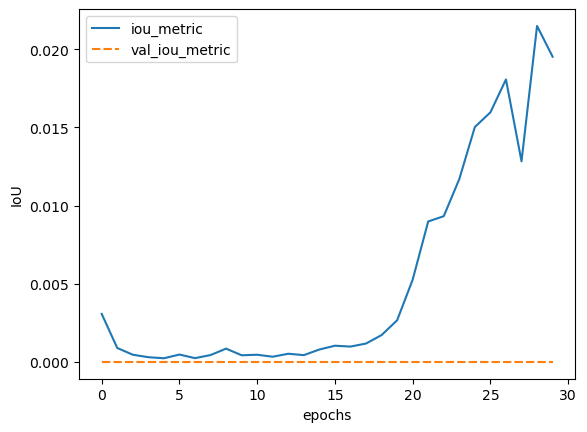

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
history_df = pd.DataFrame.from_dict(history.history)
sns.lineplot(data=history_df[['iou_metric', 'val_iou_metric']])
plt.xlabel("epochs")
plt.ylabel("IoU")

# Draw Bounding Boxes on Validation Examples

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


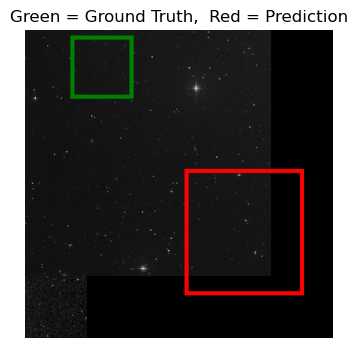

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


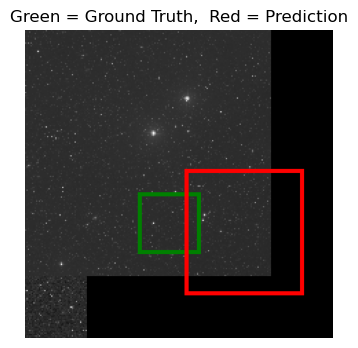

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


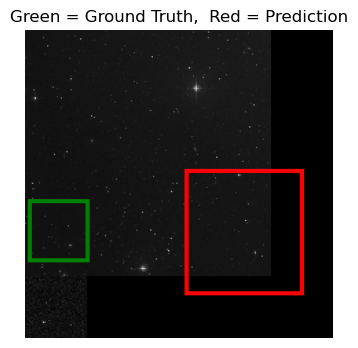

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


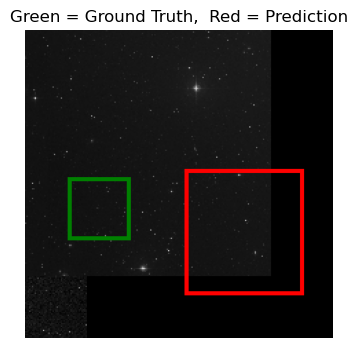

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


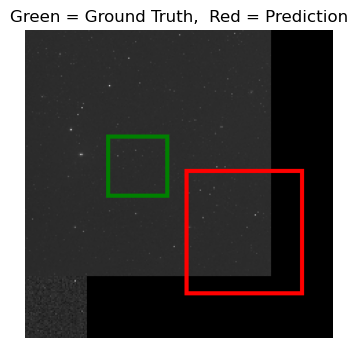

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


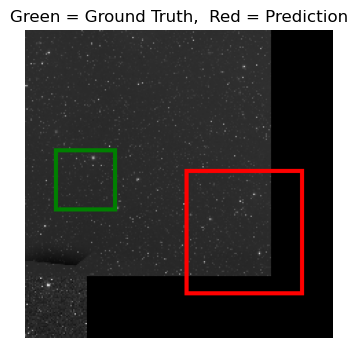

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


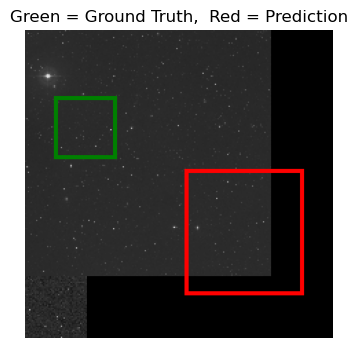

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


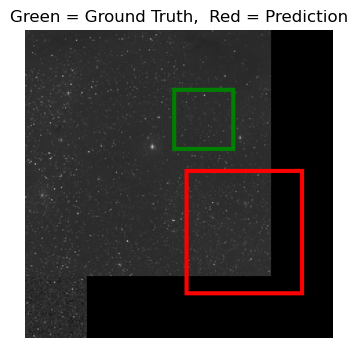

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


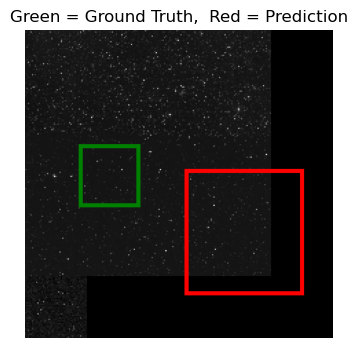

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


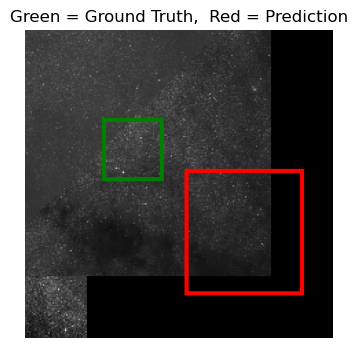

In [11]:
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


def denormalize_bbox(bbox, img_size=224):
    nx, ny, nw, nh = bbox
    xmin = int(nx * img_size)
    ymin = int(ny * img_size)
    xmax = int((nx + nw) * img_size)
    ymax = int((ny + nh) * img_size)
    return xmin, ymin, xmax, ymax


def draw_boxes(img, gt_bbox, pred_bbox, img_size=224):
    # Convert Tensor → NumPy
    if hasattr(img, "numpy"):
        img = img.numpy()

    # Convert float32 [0–1] to a uint8 [0–255]
    img = (img * 255).astype(np.uint8)

    img = Image.fromarray(img)
    draw = ImageDraw.Draw(img)


  
    gt = denormalize_bbox(gt_bbox, img_size)
    draw.rectangle(gt, outline="green", width=3)
    pr = denormalize_bbox(pred_bbox, img_size)
    draw.rectangle(pr, outline="red", width=3)

    return img


def show_validation_examples(model, val_images, val_bboxes, num=5):
    indices = np.random.choice(len(val_images), num, replace=False)

    for idx in indices:
        img = val_images[idx]
        gt = val_bboxes[idx]

        # Model expects batch dimension
        pred = model.predict(img[np.newaxis, ...])[0]

        vis = draw_boxes(img, gt, pred)

        plt.figure(figsize=(4,4))
        plt.imshow(vis)
        plt.axis("off")
        plt.title("Green = Ground Truth,  Red = Prediction")
        plt.show()

show_validation_examples(model, val_images, val_bboxes, num=10)